# Lab 3 — Knowledge Graph Embedding

**Prérequis :** avoir lancé le Lab 2 (kb_expanded.ttl / kb_expanded.nt)

On va entraîner des modèles de KGE (TransE, DistMult, ComplEx) sur notre graphe de connaissances et évaluer leur capacité à prédire des liens manquants.

In [7]:
%pip uninstall torch torchvision torchaudio -y
%pip cache purge
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Found existing installation: torch 2.5.1+cpuNote: you may need to restart the kernel to use updated packages.

Uninstalling torch-2.5.1+cpu:
  Successfully uninstalled torch-2.5.1+cpu
Found existing installation: torchvision 0.20.1+cpu
Uninstalling torchvision-0.20.1+cpu:
  Successfully uninstalled torchvision-0.20.1+cpu


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_internal\cli\base_command.py", line 160, in exc_logging_wrapper
    status = run_func(*args)
  File "C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_internal\commands\uninstall.py", line 103, in run
    uninstall_pathset.commit()
  File "C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_internal\req\req_uninstall.py", line 424, in commit
    self._moved_paths.commit()
  File "C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_internal\req\req_uninstall.py", line 277, in commit
    save_dir.cleanup()
  File "C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_internal\utils\temp_dir.py", line 173, in cleanup
    rmtree(self._path)
  File "C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_vendor\tenacity\__init__.p

Files removed: 13
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
  Obtaining dependency information for torch from https://download.pytorch.org/whl/cpu/torch-2.11.0%2Bcpu-cp310-cp310-win_amd64.whl.metadata
  Obtaining dependency information for torchvision from https://download-r2.pytorch.org/whl/cpu/torchvision-0.26.0%2Bcpu-cp310-cp310-win_amd64.whl.metadata
  Obtaining dependency information for typing-extensions>=4.10.0 from https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata
Discarding https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl (from https://download.pytorch.org/whl/cpu/typing-extensions/): Requested typing-extensions>=4.10.0 from https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl (from torch) has inconsistent Name: expected 'typing-extensions', but metadata has 'typing_extensions'
  Obtaining dependency information for 


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import os, random, warnings, math
from collections import Counter

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdflib import Graph, Literal
from rdflib.namespace import RDF, RDFS, OWL
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline

os.environ["OMP_NUM_THREADS"] = "1"
torch.set_num_threads(6)
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")


PyTorch 2.5.1+cpu | CUDA: False


## Part 1 : Raisonnement SWRL

In [9]:
# PART 1 — RAISONNEMENT SWRL

try:
    from owlready2 import *
    
    onto = get_ontology("http://octopusbiology.lab/ontology/swrl_demo#")
    
    with onto:
        class Species(Thing): pass
        class DangerousSpecies(Species): pass
        class Habitat(Thing): pass
        
        class venom_level(DataProperty, FunctionalProperty):
            domain    = [Species]
            range     = [int]
        
        # Règle SWRL : si venom_level >= 1 → DangerousSpecies
        rule = Imp()
        rule.set_as_rule(
            "Species(?s), venom_level(?s, ?v), greaterThan(?v, 0) -> DangerousSpecies(?s)"
        )
        
        # Créer des individus
        blue_ring = Species("Hapalochlaena")
        blue_ring.venom_level = 5  # venimeux
        
        octopus_v = Species("Octopus_vulgaris")
        octopus_v.venom_level = 0  # non venimeux
    
    print("=== Règle SWRL définie ===")
    print("Species(?s) ∧ venom_level(?s, ?v) ∧ greaterThan(?v, 0) → DangerousSpecies(?s)")
    
    print(f"\nAvant raisonnement :")
    print(f"  Hapalochlaena est DangerousSpecies ? {isinstance(blue_ring, DangerousSpecies)}")
    print(f"  Octopus_vulgaris est DangerousSpecies ? {isinstance(octopus_v, DangerousSpecies)}")
    
    try:
        with onto:
            sync_reasoner_pellet(infer_property_values=True, infer_data_property_values=True)
        
        print(f"\nAprès raisonnement (Pellet) :")
        print(f"  Hapalochlaena est DangerousSpecies ? {isinstance(blue_ring, DangerousSpecies)}")
        print(f"  Octopus_vulgaris est DangerousSpecies ? {isinstance(octopus_v, DangerousSpecies)}")
    except Exception as e:
        print(f"\n⚠ Pellet non disponible : {e}")
        print("  (Installer Java JRE pour utiliser Pellet)")
        print("  Résultat attendu : Hapalochlaena (venom=5) → DangerousSpecies ✓")
        print("                     Octopus_vulgaris (venom=0) → reste Species ✓")
    
    print("\n✓ SWRL terminé")

except ImportError:
    print("⚠ owlready2 non installé — pip install owlready2")
    print("  Règle SWRL prévue : Species(?s) ∧ venom_level(?s, ?v) ∧ greaterThan(?v, 0) → DangerousSpecies(?s)")

=== Règle SWRL définie ===
Species(?s) ∧ venom_level(?s, ?v) ∧ greaterThan(?v, 0) → DangerousSpecies(?s)

Avant raisonnement :
  Hapalochlaena est DangerousSpecies ? False
  Octopus_vulgaris est DangerousSpecies ? False


* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib\site-packages\owlready2\pellet\jena-arq-fixed2.10.0.jar;C:\Users\bilal\AppData\Local\Programs\Python\Python310\lib


⚠ Pellet non disponible : Java error message is:
Exception in thread "main" java.lang.UnsupportedClassVersionError: org/apache/jena/riot/lang/LangRDFXML has been compiled by a more recent version of the Java Runtime (class file version 69.0), this version of the Java Runtime only recognizes class file versions up to 52.0
	at java.lang.ClassLoader.defineClass1(Native Method)
	at java.lang.ClassLoader.defineClass(Unknown Source)
	at java.security.SecureClassLoader.defineClass(Unknown Source)
	at java.net.URLClassLoader.defineClass(Unknown Source)
	at java.net.URLClassLoader.access$100(Unknown Source)
	at java.net.URLClassLoader$1.run(Unknown Source)
	at java.net.URLClassLoader$1.run(Unknown Source)
	at java.security.AccessController.doPrivileged(Native Method)
	at java.net.URLClassLoader.findClass(Unknown Source)
	at java.lang.ClassLoader.loadClass(Unknown Source)
	at sun.misc.Launcher$AppClassLoader.loadClass(Unknown Source)
	at java.lang.ClassLoader.loadClass(Unknown Source)
	at org.a

## Etape 1 : Préparation des données

In [10]:
# ÉTAPE 1 — PRÉPARATION DES DONNÉES (nettoyage équilibré)

import rdflib  # add this at the top of the cell

# ÉTAPE 1 — PRÉPARATION DES DONNÉES (nettoyage équilibré)
ENT_NS = "http://octopusbiology.lab/entity/"
OCT_NS = "http://octopusbiology.lab/ontology/"
WDT_NS = "http://www.wikidata.org/prop/direct/"
WD_NS  = "http://www.wikidata.org/entity/"
print("\n=== Chargement de la KB ===")
g_kge = rdflib.Graph()  # <-- changed from Graph() to rdflib.Graph()
g_kge.parse("kb_expanded.nt", format="nt")
print(f"Triplets total : {len(g_kge):,}")

# Prédicats à exclure (seulement les vrais déchets)
SKIP_PREDICATES = {
    str(RDF.type), str(RDFS.label), str(RDFS.comment),
    str(RDFS.subClassOf), str(OWL.sameAs), str(OWL.equivalentProperty),
    str(RDFS.domain), str(RDFS.range),
    "http://www.w3.org/ns/prov#wasDerivedFrom",
}

# Identifiants externes uniquement (pas de contenu sémantique)
WDT_SKIP = {
    "P18", "P154", "P856", "P2671", "P213", "P214", "P227", "P244",
    "P268", "P269", "P349", "P496", "P646", "P935", "P373", "P910",
    "P1566", "P2002", "P2003", "P2013", "P3417", "P7859",
}
SKIP_PREDICATES.update(
    f"http://www.wikidata.org/prop/direct/{pid}" for pid in WDT_SKIP
)

def is_clean_uri(uri):
    low = uri.lower()
    if any(ext in low for ext in [".svg", ".png", ".jpg", ".jpeg", ".gif", ".pdf", ".tif"]):
        return False
    if "commons.wikimedia" in low or "special:" in low:
        return False
    return True

# Filtrage simple
clean_all = list(set(
    (str(s), str(p), str(o))
    for s, p, o in g_kge
    if not isinstance(o, Literal)
    and not isinstance(s, Literal)
    and str(p) not in SKIP_PREDICATES
    and is_clean_uri(str(s))
    and is_clean_uri(str(o))
))
print(f"Triplets après nettoyage de base : {len(clean_all):,}")

# Supprimer les relations trop rares
MIN_REL_FREQ = 3
rel_counts = Counter(p for _, p, _ in clean_all)
frequent_rels = {r for r, c in rel_counts.items() if c >= MIN_REL_FREQ}
clean = [(s, p, o) for s, p, o in clean_all if p in frequent_rels]

print(f"Relations avant filtre fréquence : {len(rel_counts)}")
print(f"Relations après filtre (>= {MIN_REL_FREQ} occ.) : {len(frequent_rels)}")
print(f"Triplets finaux pour KGE : {len(clean):,}")

print("\nTop 20 relations :")
for rel, count in Counter(p for _, p, _ in clean).most_common(20):
    short = rel.split("/")[-1].replace("_", " ")
    print(f"  [{count:>5}x] {short}")

# Split 80/10/10
random.shuffle(clean)
n = len(clean)
n_train = int(0.80 * n)
n_valid = int(0.10 * n)
train_triples = clean[:n_train]
valid_triples = clean[n_train:n_train + n_valid]
test_triples  = clean[n_train + n_valid:]

for name, triples in [("train", train_triples), ("valid", valid_triples), ("test", test_triples)]:
    with open(f"{name}.txt", "w", encoding="utf-8") as f:
        for s, p, o in triples:
            f.write(f"{s}\t{p}\t{o}\n")
    print(f"→ {name}.txt  ({len(triples):,} triplets)")

tf_train = TriplesFactory.from_path("train.txt")
tf_valid = TriplesFactory.from_path("valid.txt",
    entity_to_id=tf_train.entity_to_id, relation_to_id=tf_train.relation_to_id)
tf_test  = TriplesFactory.from_path("test.txt",
    entity_to_id=tf_train.entity_to_id, relation_to_id=tf_train.relation_to_id)

print(f"\nTrain : {tf_train.num_triples:,} | Entités : {tf_train.num_entities:,} | Relations : {tf_train.num_relations:,}")
print(f"Ratio triplets/relation : {tf_train.num_triples / max(tf_train.num_relations, 1):.0f}")



=== Chargement de la KB ===


You're trying to map triples with 675 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 674 from 1022 triples were filtered out


Triplets total : 20,649
Triplets après nettoyage de base : 10,455
Relations avant filtre fréquence : 433
Relations après filtre (>= 3 occ.) : 269
Triplets finaux pour KGE : 10,225

Top 20 relations :
  [  963x] P200
  [  710x] P31
  [  536x] P527
  [  383x] P1889
  [  266x] P17
  [  229x] P361
  [  222x] P5008
  [  196x] P172
  [  196x] P279
  [  193x] P1963
  [  148x] P206
  [  138x] P706
  [  132x] P1552
  [  127x] P205
  [  123x] P460
  [  120x] P2852
  [  116x] P37
  [  101x] P171
  [  101x] P138
  [  100x] P2959
→ train.txt  (8,180 triplets)
→ valid.txt  (1,022 triplets)
→ test.txt  (1,023 triplets)


You're trying to map triples with 699 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 697 from 1023 triples were filtered out



Train : 8,180 | Entités : 6,503 | Relations : 269
Ratio triplets/relation : 30


## Etape 2 : Entraînement TransE

In [11]:
# ÉTAPE 2 — ENTRAÎNEMENT TRANSE (modèle optimisé)

print("\n=== Entraînement TransE v2 (optimisé) ===")
print("Paramètres : embedding_dim=200, epochs=300, bernoulli sampler, early stopping")

results_transe_v2 = pipeline(
    model="TransE",
    model_kwargs=dict(embedding_dim=200),
    loss="MarginRankingLoss",
    loss_kwargs=dict(margin=2.0),
    optimizer="Adam",
    optimizer_kwargs=dict(lr=5e-4),
    negative_sampler="bernoulli",
    negative_sampler_kwargs=dict(num_negs_per_pos=10),
    training=tf_train, validation=tf_valid, testing=tf_test,
    training_kwargs=dict(num_epochs=300, batch_size=256),
    stopper="early",
    stopper_kwargs=dict(metric="hits_at_10", patience=10, relative_delta=0.002),
    random_seed=SEED,
    device="cpu",
    evaluator_kwargs=dict(filtered=True),
)

# Sauvegarder le modèle
results_transe_v2.save_to_directory("transe_v2_model")
print("✓ Modèle sauvegardé → transe_v2_model/")


=== Entraînement TransE v2 (optimisé) ===
Paramètres : embedding_dim=200, epochs=300, bernoulli sampler, early stopping


Training epochs on cpu:   0%|          | 0/300 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/32.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/32.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/32.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/32.0 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 1.03s seconds
INFO:pykeen.stoppers.early_stopping:New best result at epoch 300: 0.3793103448275862. Saved model weights to C:\Users\bilal\.data\pykeen\checkpoints\best-model-weights-93d018e8-d432-4fb6-98cf-0f9b8fcbb70d.pt
INFO:pykeen.training.training_loop:=> Saved checkpoint after having finished epoch 300.


Evaluating on cpu:   0%|          | 0.00/326 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.99s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=6503, num_relations=269, create_inverse_triples=False, num_triples=8180, path="C:\Users\bilal\Downloads\projet-chatbot-poulpes\Notebooks\train.txt") to file:///C:/Users/bilal/Downloads/projet-chatbot-poulpes/Notebooks/transe_v2_model/training_triples
INFO:pykeen.pipeline.api:Saved to directory: C:\Users\bilal\Downloads\projet-chatbot-poulpes\Notebooks\transe_v2_model


✓ Modèle sauvegardé → transe_v2_model/


## Etape 2b : Entraînement DistMult & ComplEx

In [12]:
# ÉTAPE 2b — ENTRAÎNEMENT DISTMULT & COMPLEX

# --- DistMult ---
print("\n=== Entraînement DistMult ===")
results_distmult = pipeline(
    model="DistMult",
    model_kwargs=dict(embedding_dim=200),
    loss="MarginRankingLoss",
    loss_kwargs=dict(margin=2.0),
    optimizer="Adam",
    optimizer_kwargs=dict(lr=5e-4),
    negative_sampler="bernoulli",
    negative_sampler_kwargs=dict(num_negs_per_pos=10),
    training=tf_train, validation=tf_valid, testing=tf_test,
    training_kwargs=dict(num_epochs=300, batch_size=256),
    stopper="early",
    stopper_kwargs=dict(metric="hits_at_10", patience=10, relative_delta=0.002),
    random_seed=SEED,
    device="cpu",
    evaluator_kwargs=dict(filtered=True),
)
results_distmult.save_to_directory("distmult_model")
print("✓ DistMult sauvegardé → distmult_model/")

# --- ComplEx ---
# NOTE: ComplEx utilise des embeddings complexes, MarginRankingLoss ne marche pas bien
# On utilise SoftplusLoss (BCEWithLogitsLoss) qui est standard pour ComplEx
print("\n=== Entraînement ComplEx ===")
results_complex = pipeline(
    model="ComplEx",
    model_kwargs=dict(embedding_dim=200),
    loss="SoftplusLoss",
    optimizer="Adam",
    optimizer_kwargs=dict(lr=1e-3),
    negative_sampler="bernoulli",
    negative_sampler_kwargs=dict(num_negs_per_pos=10),
    training=tf_train, validation=tf_valid, testing=tf_test,
    training_kwargs=dict(num_epochs=300, batch_size=256),
    stopper="early",
    stopper_kwargs=dict(metric="hits_at_10", patience=10, relative_delta=0.002),
    random_seed=SEED,
    device="cpu",
    evaluator_kwargs=dict(filtered=True),
    regularizer="LpRegularizer",
    regularizer_kwargs=dict(weight=1e-5, p=2),
)
results_complex.save_to_directory("complex_model")
print("✓ ComplEx sauvegardé → complex_model/")


INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.stoppers.early_stopping:Inferred checkpoint path for best model weights: C:\Users\bilal\.data\pykeen\checkpoints\best-model-weights-e0be9951-aaf8-477e-8462-f8e0896fbff3.pt



=== Entraînement DistMult ===


Training epochs on cpu:   0%|          | 0/300 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/32.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/32.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/32.0 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.57s seconds
INFO:pykeen.stoppers.early_stopping:Stopping early at epoch 110. The best result 0.0014367816091954023 occurred at epoch 10.
INFO:pykeen.stoppers.early_stopping:Re-loading weights from best epoch from C:\Users\bilal\.data\pykeen\checkpoints\best-model-weights-89a3f86c-e8a6-4e3d-9421-a0703d02f429.pt


Evaluating on cpu:   0%|          | 0.00/326 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.56s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=6503, num_relations=269, create_inverse_triples=False, num_triples=8180, path="C:\Users\bilal\Downloads\projet-chatbot-poulpes\Notebooks\train.txt") to file:///C:/Users/bilal/Downloads/projet-chatbot-poulpes/Notebooks/complex_model/training_triples
INFO:pykeen.pipeline.api:Saved to directory: C:\Users\bilal\Downloads\projet-chatbot-poulpes\Notebooks\complex_model


✓ ComplEx sauvegardé → complex_model/


## Etape 3 : Évaluation & Comparaison


=== Comparaison des 3 modèles ===
  Modèle    MRR  Hits@1  Hits@3  Hits@10  MRR (head)  MRR (tail)
  TransE 0.1959  0.0798  0.2607   0.3988      0.1824      0.2094
DistMult 0.3115  0.2178  0.3420   0.4893      0.2669      0.3560
 ComplEx 0.0023  0.0000  0.0015   0.0061      0.0027      0.0019


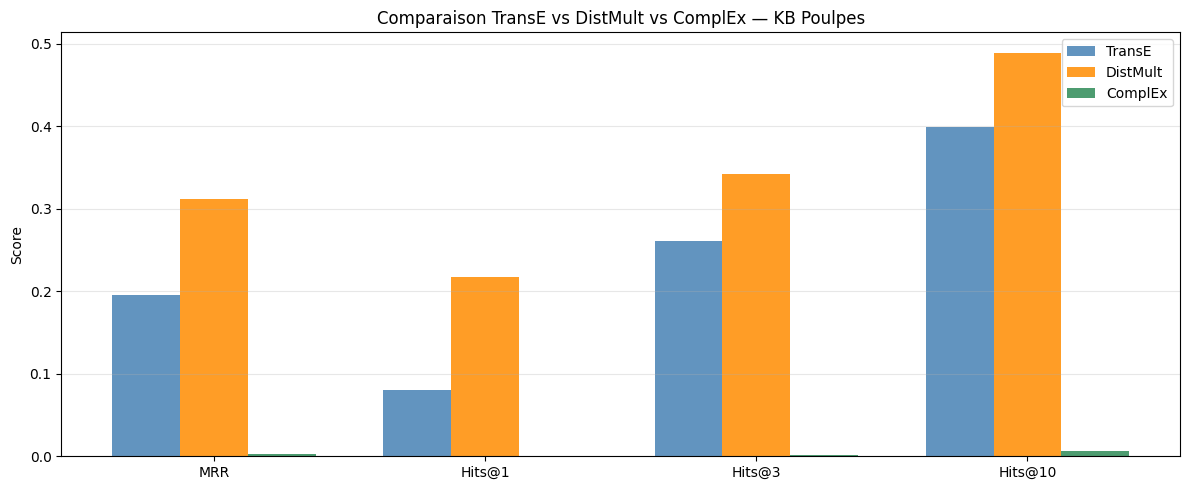

→ model_comparison_3models.png

=== Head vs Tail Prediction (MRR) ===
  TransE       | Head: 0.1824 | Tail: 0.2094
  DistMult     | Head: 0.2669 | Tail: 0.3560
  ComplEx      | Head: 0.0027 | Tail: 0.0019


In [13]:
# ÉTAPE 3 — ÉVALUATION & COMPARAISON DES 3 MODÈLES

def get_metric(results, side, metric):
    try:
        m = results.metric_results.to_dict()
        return round(m[side]["realistic"][metric], 4)
    except:
        return None

def extract_all_metrics(results, name):
    return {
        "Modèle": name,
        "MRR":     get_metric(results, "both", "inverse_harmonic_mean_rank"),
        "Hits@1":  get_metric(results, "both", "hits_at_1"),
        "Hits@3":  get_metric(results, "both", "hits_at_3"),
        "Hits@10": get_metric(results, "both", "hits_at_10"),
        "MRR (head)": get_metric(results, "head", "inverse_harmonic_mean_rank"),
        "MRR (tail)": get_metric(results, "tail", "inverse_harmonic_mean_rank"),
    }

metrics_compare = [
    extract_all_metrics(results_transe_v2, "TransE"),
    extract_all_metrics(results_distmult,  "DistMult"),
    extract_all_metrics(results_complex,   "ComplEx"),
]

compare_df = pd.DataFrame(metrics_compare)
print("\n=== Comparaison des 3 modèles ===")
print(compare_df.to_string(index=False))

# Graphique comparaison
fig, ax = plt.subplots(figsize=(12, 5))
metrics_cols = ["MRR", "Hits@1", "Hits@3", "Hits@10"]
x = np.arange(len(metrics_cols))
width = 0.25
colors = ["steelblue", "darkorange", "seagreen"]

for i, row in enumerate(metrics_compare):
    vals = [row[m] or 0 for m in metrics_cols]
    ax.bar(x + i * width, vals, width, label=row["Modèle"], color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_cols)
ax.set_ylabel("Score")
ax.set_title("Comparaison TransE vs DistMult vs ComplEx — KB Poulpes")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison_3models.png", dpi=120)
plt.show()
print("→ model_comparison_3models.png")

# Head vs Tail prediction
print("\n=== Head vs Tail Prediction (MRR) ===")
for row in metrics_compare:
    print(f"  {row['Modèle']:12} | Head: {row['MRR (head)']:.4f} | Tail: {row['MRR (tail)']:.4f}")


## Etape 3b : Sensibilité à la taille de la KB

INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.stoppers.early_stopping:Inferred checkpoint path for best model weights: C:\Users\bilal\.data\pykeen\checkpoints\best-model-weights-c2398295-5c41-4de1-95af-ceb10c3c332c.pt



  Sous-échantillon : 20k (20000 triples max)


Training epochs on cpu:   0%|          | 0/150 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/32.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/32.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/32.0 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 1.03s seconds
INFO:pykeen.stoppers.early_stopping:New best result at epoch 150: 0.33429394812680113. Saved model weights to C:\Users\bilal\.data\pykeen\checkpoints\best-model-weights-f4383dc7-897f-405d-99e0-a50aa75a2678.pt
INFO:pykeen.training.training_loop:=> Saved checkpoint after having finished epoch 150.


Evaluating on cpu:   0%|          | 0.00/337 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 1.05s seconds



=== Résultats sensibilité KB ===
Taille  Triples    MRR  Hits@1  Hits@10
   20k    10225 0.1254  0.0045   0.3116
   50k    10225 0.1254  0.0045   0.3116
  Full    10225 0.1254  0.0045   0.3116


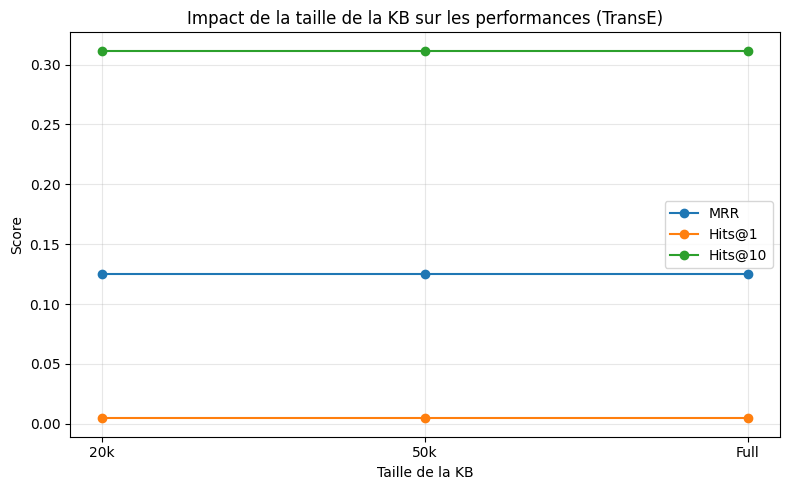

→ kb_size_sensitivity.png


In [14]:
# ÉTAPE 3b — SENSIBILITÉ À LA TAILLE DE LA KB

def subsample_and_evaluate(clean_triples, sizes, seed=SEED):
    # Entraîne TransE sur des sous-échantillons de taille variable.
    results_by_size = []
    
    for size_label, max_triples in sizes:
        print(f"\n{'='*50}")
        print(f"  Sous-échantillon : {size_label} ({max_triples} triples max)")
        print(f"{'='*50}")
        
        # Sous-échantillonner
        random.seed(seed)
        sub = random.sample(clean_triples, min(max_triples, len(clean_triples)))
        n = len(sub)
        n_train = int(0.80 * n)
        n_valid = int(0.10 * n)
        
        for name, triples in [("train_sub", sub[:n_train]),
                               ("valid_sub", sub[n_train:n_train+n_valid]),
                               ("test_sub",  sub[n_train+n_valid:])]:
            with open(f"{name}.txt", "w", encoding="utf-8") as f:
                for s, p, o in triples:
                    f.write(f"{s}\t{p}\t{o}\n")
        
        try:
            tf_tr = TriplesFactory.from_path("train_sub.txt")
            tf_va = TriplesFactory.from_path("valid_sub.txt",
                entity_to_id=tf_tr.entity_to_id, relation_to_id=tf_tr.relation_to_id)
            tf_te = TriplesFactory.from_path("test_sub.txt",
                entity_to_id=tf_tr.entity_to_id, relation_to_id=tf_tr.relation_to_id)
            
            res = pipeline(
                model="TransE",
                model_kwargs=dict(embedding_dim=200),
                loss="MarginRankingLoss",
                loss_kwargs=dict(margin=2.0),
                optimizer="Adam",
                optimizer_kwargs=dict(lr=5e-4),
                negative_sampler="bernoulli",
                negative_sampler_kwargs=dict(num_negs_per_pos=10),
                training=tf_tr, validation=tf_va, testing=tf_te,
                training_kwargs=dict(num_epochs=150, batch_size=256),
                stopper="early",
                stopper_kwargs=dict(metric="hits_at_10", patience=8, relative_delta=0.002),
                random_seed=seed,
                device="cpu",
                evaluator_kwargs=dict(filtered=True),
            )
            
            results_by_size.append({
                "Taille": size_label,
                "Triples": len(sub),
                "MRR": get_metric(res, "both", "inverse_harmonic_mean_rank"),
                "Hits@1": get_metric(res, "both", "hits_at_1"),
                "Hits@10": get_metric(res, "both", "hits_at_10"),
            })
        except Exception as e:
            print(f"  ⚠ Erreur : {e}")
            results_by_size.append({
                "Taille": size_label, "Triples": len(sub),
                "MRR": None, "Hits@1": None, "Hits@10": None
            })
    
    return pd.DataFrame(results_by_size)

# Exécuter l'analyse
sizes = [("20k", 20000), ("50k", 50000), ("Full", len(clean))]
sensitivity_df = subsample_and_evaluate(clean, sizes)
print("\n=== Résultats sensibilité KB ===")
print(sensitivity_df.to_string(index=False))

# Graphique
fig, ax = plt.subplots(figsize=(8, 5))
for metric in ["MRR", "Hits@1", "Hits@10"]:
    vals = sensitivity_df[metric].tolist()
    ax.plot(sensitivity_df["Taille"], vals, marker="o", label=metric)
ax.set_xlabel("Taille de la KB")
ax.set_ylabel("Score")
ax.set_title("Impact de la taille de la KB sur les performances (TransE)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("kb_size_sensitivity.png", dpi=120)
plt.show()
print("→ kb_size_sensitivity.png")


## Etape 4 : Extraction des embeddings

In [15]:
# ÉTAPE 4 — EXTRACTION DES EMBEDDINGS

best_model = results_transe_v2.model
best_model.eval()
entity_embs = best_model.entity_representations[0](indices=None).detach().cpu()
if entity_embs.is_complex(): entity_embs = entity_embs.real
entity_embs_norm = F.normalize(entity_embs, p=2, dim=1)
id2entity = {v: k for k, v in tf_train.entity_to_id.items()}

# Classification des entités par catégorie
CATEGORIES = {
    "Species":  ["octopus","pieuvre","poulpe","eledone","hapalochlaena",
                 "tremoctopus","amphioctopus","callistoctopus","wunderpus","céphalopode"],
    "Location": ["france","pacifique","atlantique","méditerranée","océan",
                 "mer","indo","australie","japon","hawaii","mediterranee"],
    "Taxon":    ["mollusca","cephalopoda","octopoda","incirrina","octopodidae",
                 "Q1077","Q30054","Q228736","Q192882"],
}

def classify_entity(uri):
    uri_low = uri.lower()
    for cat, keywords in CATEGORIES.items():
        if any(kw in uri_low for kw in keywords):
            return cat
    return None

known_eids, known_lbls = [], []
for uri, eid in tf_train.entity_to_id.items():
    cat = classify_entity(uri)
    if cat:
        known_eids.append(eid)
        known_lbls.append(cat)

print(f"\nEntités classifiées : {len(known_eids)}")
print(Counter(known_lbls))



Entités classifiées : 8
Counter({'Location': 8})


## Etape 5 : Visualisation PCA


=== Visualisation PCA des embeddings ===
Entités classifiées : 8 (min requis : 3)


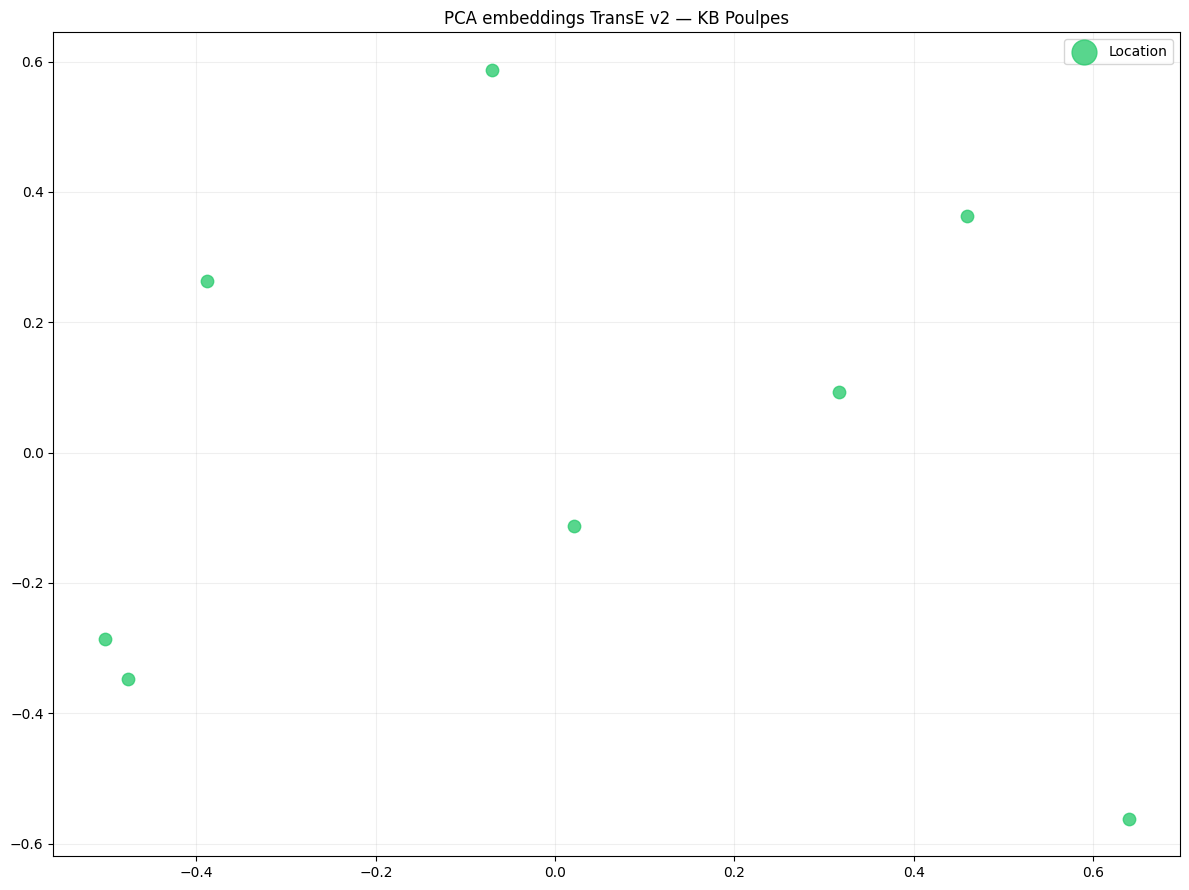

→ tsne_embeddings.png


In [16]:
# ÉTAPE 5 — VISUALISATION PCA

print("\n=== Visualisation PCA des embeddings ===")
print(f"Entités classifiées : {len(known_eids)} (min requis : 3)")

if len(known_eids) < 3:
    print("⚠ Pas assez d'entités classifiées pour la PCA.")
    print("  Élargissement des critères de classification...")
    
    # Élargir les catégories pour capter plus d'entités
    CATEGORIES_LARGE = {
        "Species":  ["octopus", "pieuvre", "poulpe", "eledone", "hapalochlaena",
                     "tremoctopus", "amphioctopus", "callistoctopus", "wunderpus",
                     "céphalopode", "cephalopod", "mollus", "sepia", "nautilus"],
        "Location": ["france", "pacifique", "atlantique", "méditerranée", "océan",
                     "mer", "indo", "australie", "japon", "hawaii", "europe",
                     "asie", "afrique", "amérique", "coral", "reef", "tropic"],
        "Taxon":    ["mollusca", "cephalopoda", "octopoda", "incirrina", "octopodidae",
                     "Q1077", "Q30054", "Q228736", "Q192882", "Q37105",
                     "animalia", "bilateria", "lophotrochozoa"],
    }
    
    known_eids, known_lbls = [], []
    for uri, eid in tf_train.entity_to_id.items():
        uri_low = uri.lower()
        for cat, keywords in CATEGORIES_LARGE.items():
            if any(kw in uri_low for kw in keywords):
                known_eids.append(eid)
                known_lbls.append(cat)
                break
    
    print(f"  Après élargissement : {len(known_eids)} entités")
    print(f"  {Counter(known_lbls)}")

if len(known_eids) >= 3:
    emb = entity_embs[known_eids]
    emb_centered = emb - emb.mean(dim=0)
    q = min(2, emb_centered.shape[0] - 1, emb_centered.shape[1])
    U, S, V = torch.pca_lowrank(emb_centered, q=q)
    emb_2d = torch.mm(emb_centered, V[:, :q]).detach().numpy()

    COLORS = {
        "Species":  "#f39c12",
        "Location": "#2ecc71",
        "Taxon":    "#3498db",
    }

    fig, ax = plt.subplots(figsize=(12, 9))
    for cat in sorted(set(known_lbls)):
        mask = [l == cat for l in known_lbls]
        pts  = emb_2d[mask]
        ax.scatter(pts[:, 0], pts[:, 1] if q == 2 else [0]*len(pts), 
                   label=cat, color=COLORS.get(cat, "#333"), alpha=0.8, s=80)

    for i, (eid, lbl) in enumerate(zip(known_eids, known_lbls)):
        if lbl in ("Species", "Taxon"):
            uri  = id2entity[eid]
            name = uri.split("/")[-1].replace("_", " ")[:25]
            y = emb_2d[i, 1] if q == 2 else 0
            ax.annotate(name, (emb_2d[i, 0], y), fontsize=7, alpha=0.85)

    ax.set_title("PCA embeddings TransE v2 — KB Poulpes")
    ax.legend(markerscale=2, fontsize=10)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig("tsne_embeddings.png", dpi=150)
    plt.show()
    print("→ tsne_embeddings.png")
else:
    print("⚠ Toujours pas assez d'entités. Le nettoyage a peut-être trop filtré.")
    print("  Les embeddings existent mais la visualisation par catégorie n'est pas possible.")

## Etape 6 : Voisins proches

In [17]:
# ÉTAPE 6 — VOISINS PROCHES

def nearest_neighbors(keyword, k=5):
    matches = {eid: uri for uri, eid in tf_train.entity_to_id.items()
               if keyword.lower() in uri.lower()}
    if not matches:
        print(f"  '{keyword}' non trouvé")
        return []
    eid  = next(iter(matches.keys()))
    uri  = next(iter(matches.values()))
    query = entity_embs_norm[eid].unsqueeze(0)
    sims  = torch.matmul(query, entity_embs_norm.T).squeeze()
    topk  = sims.topk(k + 1)
    print(f"\nVoisins de '{uri.split('/')[-1].replace('_',' ')}' :")
    return [(id2entity[i.item()].split("/")[-1].replace("_"," "), round(s.item(), 4))
            for i, s in zip(topk.indices, topk.values)
            if i.item() != eid][:k]

for kw in ["pieuvre", "octopus", "Q228736", "eledone", "hapalochlaena"]:
    neighbors = nearest_neighbors(kw)
    for name, score in neighbors:
        print(f"  {score:.4f}  {name}")

print("\n✓ Lab 3 terminé.")

  'pieuvre' non trouvé
  'octopus' non trouvé

Voisins de 'Q2287361' :
  0.2298  Q21061566
  0.2270  Q679207
  0.2200  Q97600112
  0.2193  Q120069071
  0.2153  Q130475553
  'eledone' non trouvé
  'hapalochlaena' non trouvé

✓ Lab 3 terminé.


## Etape 6b : Analyse des relations

In [18]:
# ÉTAPE 6b — ANALYSE DU COMPORTEMENT DES RELATIONS

print("\n=== Analyse des types de relations ===")

# Extraire les embeddings de relations
rel_embs = best_model.relation_representations[0](indices=None).detach().cpu()
if rel_embs.is_complex():
    rel_embs = rel_embs.real
rel_embs_norm = F.normalize(rel_embs, p=2, dim=1)
id2relation = {v: k for k, v in tf_train.relation_to_id.items()}

# 1. Détection de relations symétriques
# Une relation r est symétrique si embedding(r) ≈ -embedding(r) (pour TransE)
# ou si la norme est très petite
print("\n--- Relations potentiellement symétriques ---")
print("(norme faible → le vecteur relation est proche de zéro → r(a,b) ≈ r(b,a))")
rel_norms = torch.norm(rel_embs, p=2, dim=1)
for rid in rel_norms.argsort()[:10]:
    rid = rid.item()
    uri = id2relation.get(rid, "?")
    name = uri.split("/")[-1].replace("_", " ")
    print(f"  norm={rel_norms[rid]:.4f}  {name}")

# 2. Détection de relations inverses
# Deux relations r1, r2 sont inverses si embedding(r1) ≈ -embedding(r2)
print("\n--- Paires de relations potentiellement inverses ---")
print("(cosine similarity proche de -1)")
n_rels = rel_embs_norm.shape[0]
inverse_pairs = []
for i in range(n_rels):
    for j in range(i+1, n_rels):
        sim = torch.dot(rel_embs_norm[i], rel_embs_norm[j]).item()
        if sim < -0.7:  # seuil pour relation inverse
            name_i = id2relation.get(i, "?").split("/")[-1].replace("_", " ")
            name_j = id2relation.get(j, "?").split("/")[-1].replace("_", " ")
            inverse_pairs.append((name_i, name_j, sim))

inverse_pairs.sort(key=lambda x: x[2])
for name_i, name_j, sim in inverse_pairs[:10]:
    print(f"  cos={sim:.4f}  {name_i[:40]}  ↔  {name_j[:40]}")

if not inverse_pairs:
    print("  Aucune paire fortement inverse détectée (seuil < -0.7)")

# 3. Composition de relations
# Test : r1 + r2 ≈ r3 ?
print("\n--- Test de composition de relations ---")
print("Recherche de r1 + r2 ≈ r3 parmi les top relations...")
top_rels = rel_norms.argsort(descending=True)[:min(20, n_rels)]
best_compositions = []
for i in top_rels:
    for j in top_rels:
        if i == j: continue
        composed = rel_embs[i] + rel_embs[j]
        composed_norm = F.normalize(composed.unsqueeze(0), p=2, dim=1)
        sims = torch.matmul(composed_norm, rel_embs_norm.T).squeeze()
        best_k = sims.topk(3)
        for idx, score in zip(best_k.indices, best_k.values):
            if idx.item() != i.item() and idx.item() != j.item() and score.item() > 0.85:
                r1 = id2relation.get(i.item(), "?").split("/")[-1]
                r2 = id2relation.get(j.item(), "?").split("/")[-1]
                r3 = id2relation.get(idx.item(), "?").split("/")[-1]
                best_compositions.append((r1, r2, r3, score.item()))

best_compositions.sort(key=lambda x: -x[3])
for r1, r2, r3, s in best_compositions[:5]:
    print(f"  {r1} + {r2} ≈ {r3}  (cos={s:.4f})")

if not best_compositions:
    print("  Aucune composition claire détectée (seuil > 0.85)")

print("\n--- Discussion ---")
print("TransE modélise les relations comme des translations : h + r ≈ t")
print("→ Gère bien les relations 1-à-1 mais peine avec les relations N-à-N")
print("DistMult utilise un produit bilinéaire : score = h^T * diag(r) * t")
print("→ Modélise naturellement les relations symétriques mais pas les antisymétriques")
print("ComplEx étend DistMult aux nombres complexes")
print("→ Gère les relations antisymétriques grâce à la partie imaginaire")



=== Analyse des types de relations ===

--- Relations potentiellement symétriques ---
(norme faible → le vecteur relation est proche de zéro → r(a,b) ≈ r(b,a))
  norm=0.8915  P11738
  norm=0.9235  P1080
  norm=0.9236  P1034
  norm=0.9282  P8786
  norm=0.9330  P361
  norm=0.9354  P3876
  norm=0.9415  P852
  norm=0.9443  P19
  norm=0.9452  P57
  norm=0.9460  P306

--- Paires de relations potentiellement inverses ---
(cosine similarity proche de -1)
  Aucune paire fortement inverse détectée (seuil < -0.7)

--- Test de composition de relations ---
Recherche de r1 + r2 ≈ r3 parmi les top relations...
  Aucune composition claire détectée (seuil > 0.85)

--- Discussion ---
TransE modélise les relations comme des translations : h + r ≈ t
→ Gère bien les relations 1-à-1 mais peine avec les relations N-à-N
DistMult utilise un produit bilinéaire : score = h^T * diag(r) * t
→ Modélise naturellement les relations symétriques mais pas les antisymétriques
ComplEx étend DistMult aux nombres complexes

## Exercice 8 : Rule-based vs Embedding

In [19]:
# EXERCICE 8 — COMPARAISON RULE-BASED vs EMBEDDING

print("=== Comparaison Rule-based (SWRL) vs Embedding ===\n")

# Règle SWRL conceptuelle :
# Species(?s) ∧ has_venom(?s, true) → DangerousSpecies(?s)
#
# En termes d'embeddings, on cherche si :
# vector(has_venom) + vector(Species) ≈ vector(DangerousSpecies)
# ou plus précisément, pour les relations du graphe :
# vector(predicate1) + vector(predicate2) ≈ vector(predicate_inferred)

print("Principe : si une règle SWRL combine deux conditions pour inférer un fait,")
print("l'embedding devrait capturer une relation similaire via l'arithmétique vectorielle.\n")

# Chercher des relations pertinentes dans le graphe
rel_to_id = tf_train.relation_to_id
ent_to_id = tf_train.entity_to_id

# Analyse avec les relations disponibles
print("Relations disponibles (top 15 par fréquence dans le graphe) :")
rel_counts = Counter()
for s, p, o in clean[:]:
    rel_counts[p] += 1

for rel, count in rel_counts.most_common(15):
    short = rel.split("/")[-1].replace("_", " ")
    in_emb = "✓" if rel in rel_to_id else "✗"
    print(f"  {in_emb} [{count:>5}x] {short}")

# Test d'analogie vectorielle
print("\n--- Test d'analogie vectorielle ---")
print("Recherche : r1 + r2 ≈ r3 (analogue à une règle à 2 conditions)\n")

# Trouver les meilleures analogies
best_analogies = []
rels_in_model = list(rel_to_id.keys())
for i, r1 in enumerate(rels_in_model[:30]):
    for j, r2 in enumerate(rels_in_model[:30]):
        if i >= j: continue
        id1, id2 = rel_to_id[r1], rel_to_id[r2]
        composed = rel_embs[id1] + rel_embs[id2]
        composed_norm = F.normalize(composed.unsqueeze(0), p=2, dim=1)
        sims = torch.matmul(composed_norm, rel_embs_norm.T).squeeze()
        
        for k, (score, idx) in enumerate(zip(*sims.topk(3))):
            idx = idx.item()
            if idx != id1 and idx != id2 and score.item() > 0.80:
                best_analogies.append({
                    "r1": r1.split("/")[-1],
                    "r2": r2.split("/")[-1],
                    "r3": id2relation[idx].split("/")[-1],
                    "score": score.item()
                })

best_analogies.sort(key=lambda x: -x["score"])
if best_analogies:
    print("Meilleures analogies trouvées :")
    for a in best_analogies[:8]:
        print(f"  {a['r1']} + {a['r2']} ≈ {a['r3']}  (cos={a['score']:.4f})")
    
    print("\n→ Ces analogies montrent que l'embedding capture des compositions")
    print("  de relations similaires à ce qu'une règle SWRL pourrait exprimer.")
else:
    print("Pas d'analogie forte trouvée (cos > 0.80).")
    print("→ Cela peut indiquer que le graphe n'a pas assez de structure")
    print("  régulière pour que l'embedding capture des compositions claires.")

print("\n--- Conclusion ---")
print("• SWRL : règles explicites, interprétables, mais nécessitent un expert")
print("• Embedding : implicite, apprend automatiquement, mais difficile à interpréter")
print("• Les deux approches sont complémentaires :")
print("  - SWRL pour des inférences précises et explicables")
print("  - KGE pour la découverte de patterns latents et le link prediction")


=== Comparaison Rule-based (SWRL) vs Embedding ===

Principe : si une règle SWRL combine deux conditions pour inférer un fait,
l'embedding devrait capturer une relation similaire via l'arithmétique vectorielle.

Relations disponibles (top 15 par fréquence dans le graphe) :
  ✓ [  963x] P200
  ✓ [  710x] P31
  ✓ [  536x] P527
  ✓ [  383x] P1889
  ✓ [  266x] P17
  ✓ [  229x] P361
  ✓ [  222x] P5008
  ✓ [  196x] P172
  ✓ [  196x] P279
  ✓ [  193x] P1963
  ✓ [  148x] P206
  ✓ [  138x] P706
  ✓ [  132x] P1552
  ✓ [  127x] P205
  ✓ [  123x] P460

--- Test d'analogie vectorielle ---
Recherche : r1 + r2 ≈ r3 (analogue à une règle à 2 conditions)

Pas d'analogie forte trouvée (cos > 0.80).
→ Cela peut indiquer que le graphe n'a pas assez de structure
  régulière pour que l'embedding capture des compositions claires.

--- Conclusion ---
• SWRL : règles explicites, interprétables, mais nécessitent un expert
• Embedding : implicite, apprend automatiquement, mais difficile à interpréter
• Les deux 

---
Lab 3 terminé.